In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/healthcare-dataset-stroke-data.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Explore The structure

In [ ]:
df.head(20)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


#Types of data

In [ ]:
df.dtypes

,0
id,int64
gender,object
age,float64
hypertension,int64
heart_disease,int64
ever_married,object
work_type,object
Residence_type,object
avg_glucose_level,float64
bmi,float64


#Feel for the scale of the dataset

In [ ]:
df.shape

(5110, 12)

#Check for duplicates

In [ ]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicated rows: {duplicate_count}")

if duplicate_count > 0:
    display(df[df.duplicated()])

Number of duplicated rows: 0


#Whats  Missing

In [ ]:
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found.")

Missing values per column:
bmi    201
dtype: int64


#Get average BMI for NaN values updated by Age and Gender

In [ ]:
df['bmi'] = df['bmi'].fillna(df.groupby(['gender', 'age'])['bmi'].transform('mean'))

# Check if any missing values remain (in case some age/gender combos were all NaN)
remaining_nulls = df['bmi'].isnull().sum()
print(f"Remaining missing BMI values: {remaining_nulls}")

if remaining_nulls > 0:
    # Fallback to just gender mean if age-specific mean wasn't available
    df['bmi'] = df['bmi'].fillna(df.groupby('gender')['bmi'].transform('mean'))
    print(f"Final missing BMI values after fallback: {df['bmi'].isnull().sum()}")

Remaining missing BMI values: 1
Final missing BMI values after fallback: 0


#Save a new updated Excel with Nan Values replaced with averages

In [ ]:
output_path = '/content/drive/MyDrive/Colab Notebooks/healthcare-dataset-stroke-data-updated.csv'
df.to_csv(output_path, index=False)
print(f'File saved successfully to: {output_path}')

File saved successfully to: /content/drive/MyDrive/Colab Notebooks/healthcare-dataset-stroke-data-updated.csv


In [ ]:
df_updated = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/healthcare-dataset-stroke-data-updated.csv')
display(df_updated.head())

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,29.879487,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1


#Now none missing- Check

In [ ]:
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found.")

Missing values per column:
No missing values found.


#Descriptive analytics

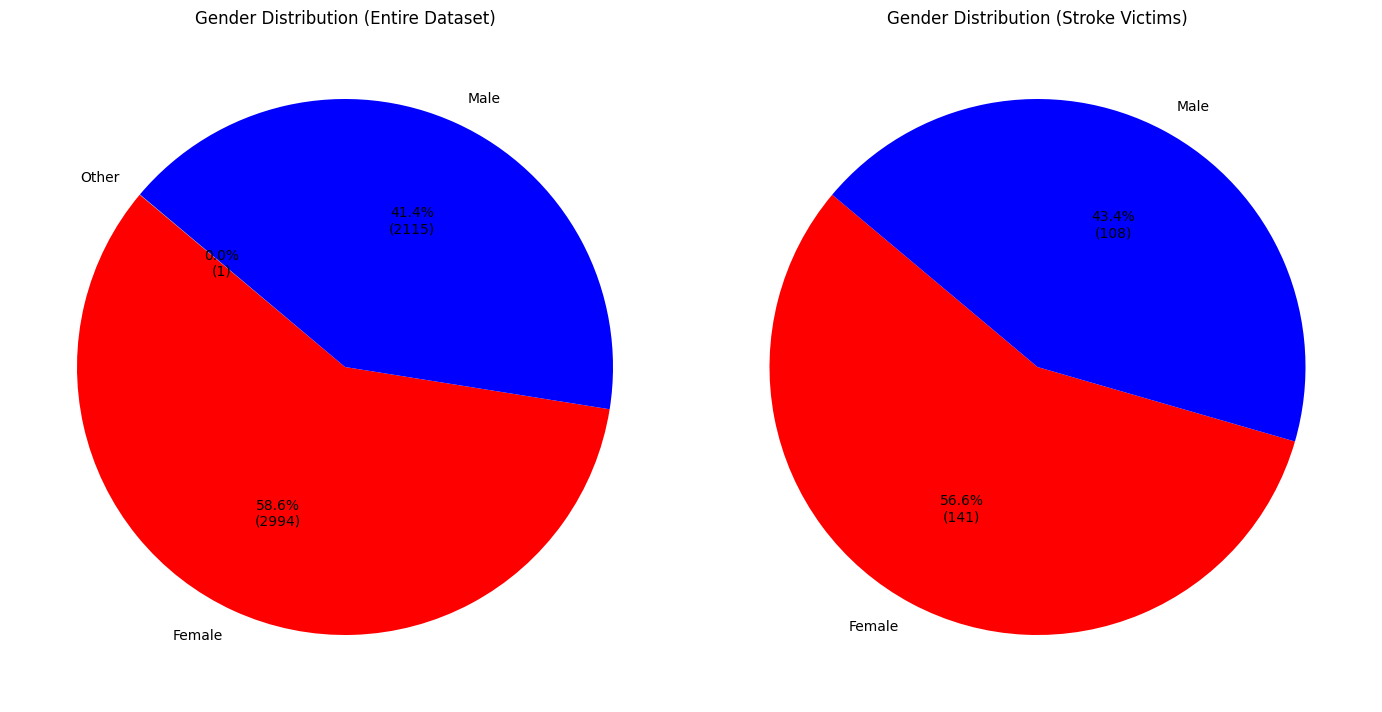

In [ ]:
import matplotlib.pyplot as plt

# Filter out 'Other' gender for cleaner visualization if necessary, or include it
gender_all = df_updated['gender'].value_counts()
gender_stroke = df_updated[df_updated['stroke'] == 1]['gender'].value_counts()

def func(pct, allvals):
    absolute = int(np.round(pct/100.*np.sum(allvals)))
    return f"{pct:.1f}%\n({absolute:d})"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Mapping colors
colors = {'Female': 'red', 'Male': 'blue', 'Other': 'grey'}

# Chart 1: Entire Dataset
ax1.pie(gender_all, labels=gender_all.index,
        autopct=lambda pct: func(pct, gender_all),
        colors=[colors.get(x, 'grey') for x in gender_all.index],
        startangle=140)
ax1.set_title('Gender Distribution (Entire Dataset)')

# Chart 2: Positive Stroke Cases (stroke=1)
ax2.pie(gender_stroke, labels=gender_stroke.index,
        autopct=lambda pct: func(pct, gender_stroke),
        colors=[colors.get(x, 'grey') for x in gender_stroke.index],
        startangle=140)
ax2.set_title('Gender Distribution (Stroke Victims)')

plt.tight_layout()
plt.show()

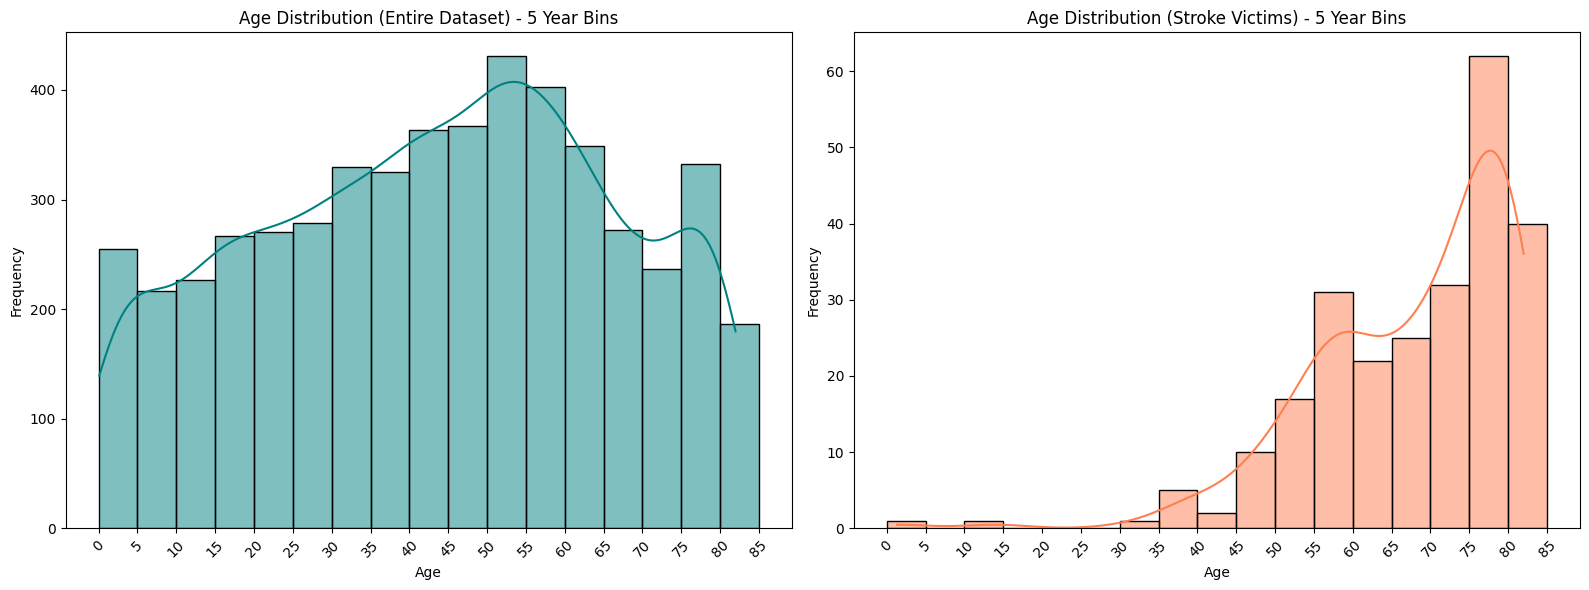

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Calculate bins in increments of 5
min_age = 0
max_age = df_updated['age'].max()
age_bins = np.arange(min_age, max_age + 5, 5)

# Set up the figure for two plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Age distribution for the entire dataset
sns.histplot(df_updated['age'], kde=True, ax=ax1, color='teal', bins=age_bins)
ax1.set_title('Age Distribution (Entire Dataset) - 5 Year Bins')
ax1.set_xlabel('Age')
ax1.set_ylabel('Frequency')
ax1.set_xticks(age_bins)
plt.setp(ax1.get_xticklabels(), rotation=45)

# Plot 2: Age distribution for stroke victims (stroke == 1)
stroke_victims_age = df_updated[df_updated['stroke'] == 1]['age']
sns.histplot(stroke_victims_age, kde=True, ax=ax2, color='coral', bins=age_bins)
ax2.set_title('Age Distribution (Stroke Victims) - 5 Year Bins')
ax2.set_xlabel('Age')
ax2.set_ylabel('Frequency')
ax2.set_xticks(age_bins)
plt.setp(ax2.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Filter for stroke victims and sort by age
stroke_victims = df_updated[df_updated['stroke'] == 1].sort_values('age')

print("--- 10 Youngest Stroke Victims ---")
display(stroke_victims.head(10)[['id', 'gender', 'age', 'stroke']])

print("\n--- 10 Oldest Stroke Victims ---")
display(stroke_victims.tail(10)[['id', 'gender', 'age', 'stroke']])

--- 10 Youngest Stroke Victims ---


,id,gender,age,stroke
162,69768,Female,1.32,1
245,49669,Female,14.00,1
182,39912,Female,32.00,1
118,31720,Female,38.00,1
133,31563,Female,38.00,1
49,36338,Female,39.00,1
228,31154,Female,39.00,1
210,33943,Female,39.00,1
31,33879,Male,42.00,1
79,42117,Male,43.00,1



--- 10 Oldest Stroke Victims ---


,id,gender,age,stroke
206,37060,Female,81.0,1
42,61960,Male,82.0,1
32,39373,Female,82.0,1
35,712,Female,82.0,1
23,64778,Male,82.0,1
56,38829,Female,82.0,1
187,67895,Female,82.0,1
140,20439,Male,82.0,1
128,37132,Male,82.0,1
188,30184,Male,82.0,1


/tmp/ipykernel_2345/2734373430.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_updated, x=col, ax=axes[i], palette='viridis')
/tmp/ipykernel_2345/2734373430.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_updated, x=col, ax=axes[i], palette='viridis')
/tmp/ipykernel_2345/2734373430.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_updated, x=col, ax=axes[i], palette='viridis')
/tmp/ipykernel_2345/2734373430.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be r

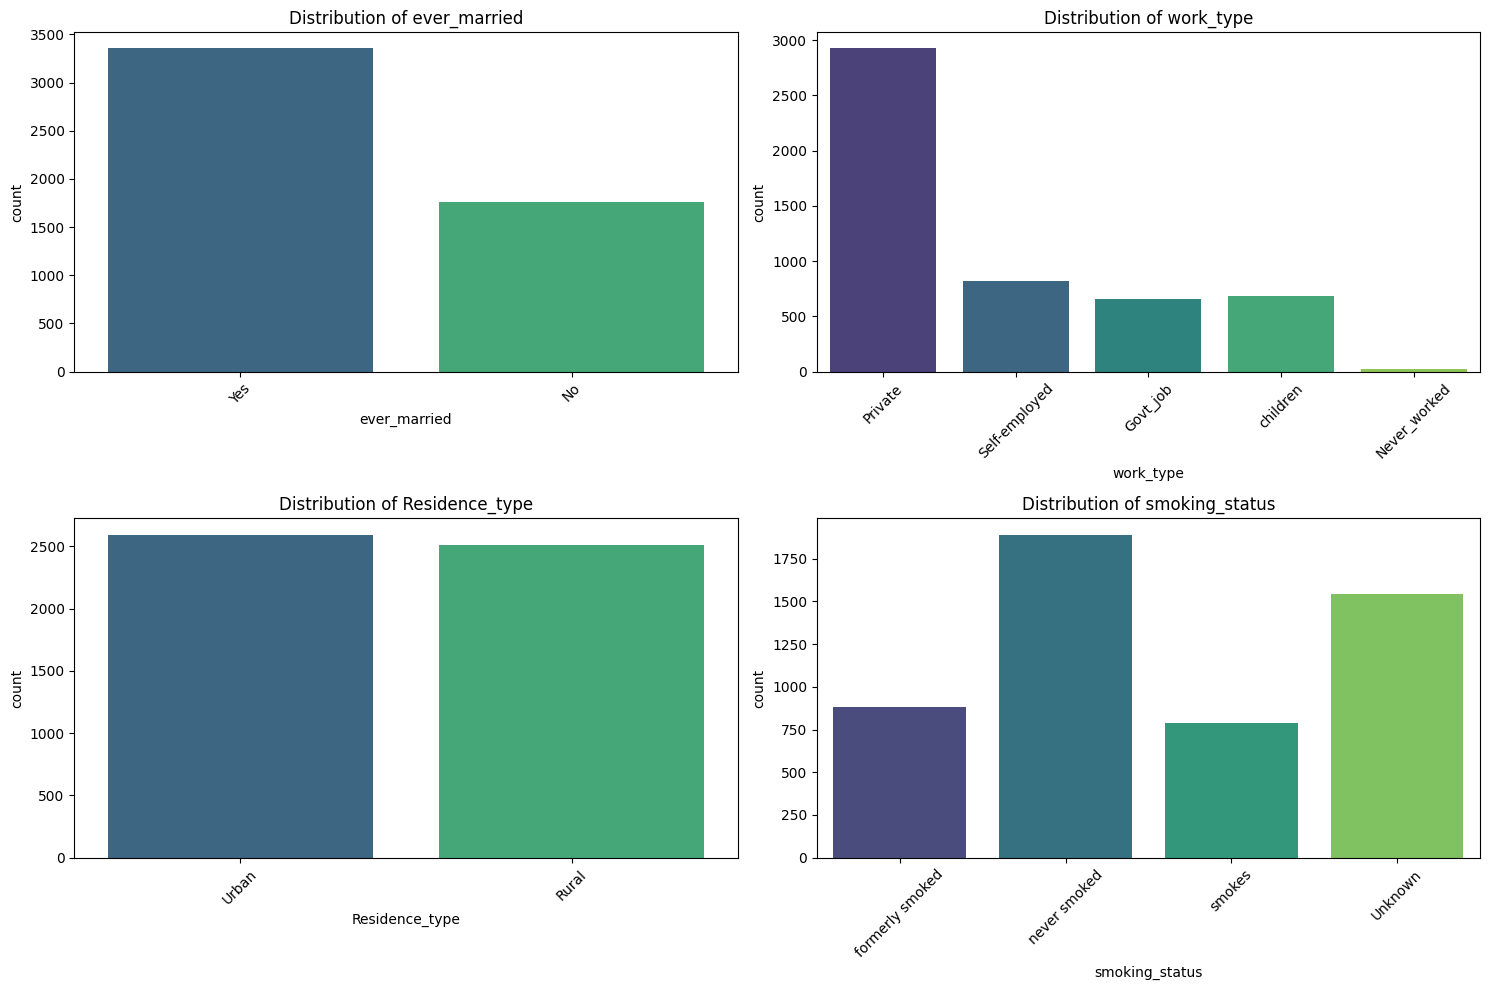

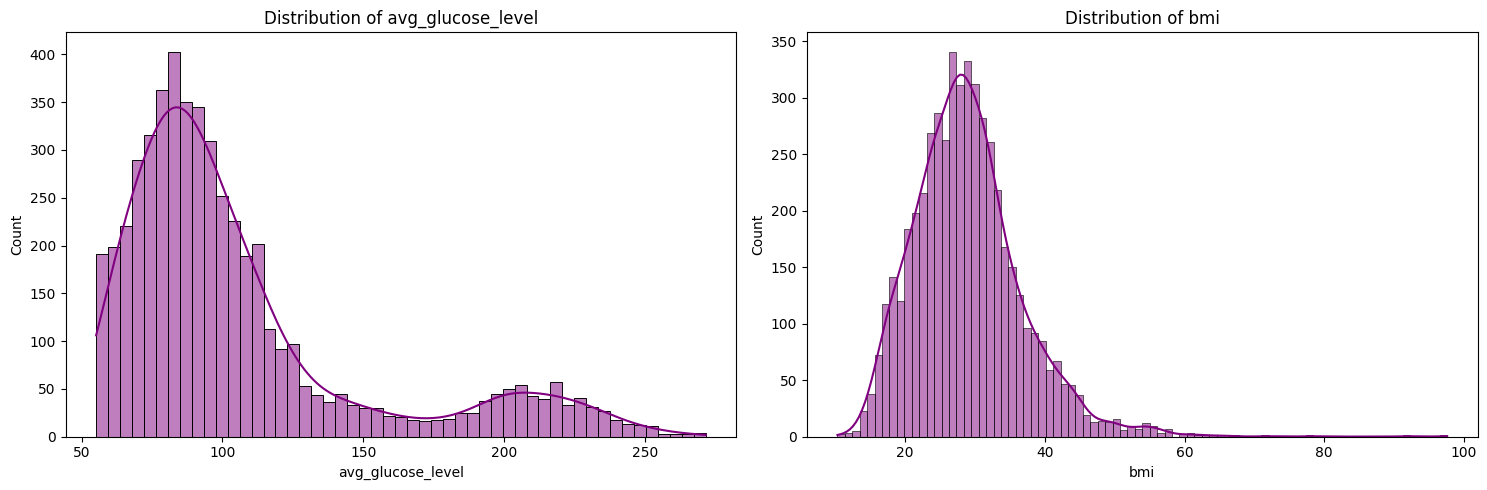

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of columns to visualize
cat_cols = ['ever_married', 'work_type', 'Residence_type', 'smoking_status']
num_cols = ['avg_glucose_level', 'bmi']

# Plot categorical columns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(data=df_updated, x=col, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Plot numerical columns
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for i, col in enumerate(num_cols):
    sns.histplot(df_updated[col], kde=True, ax=axes[i], color='purple')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

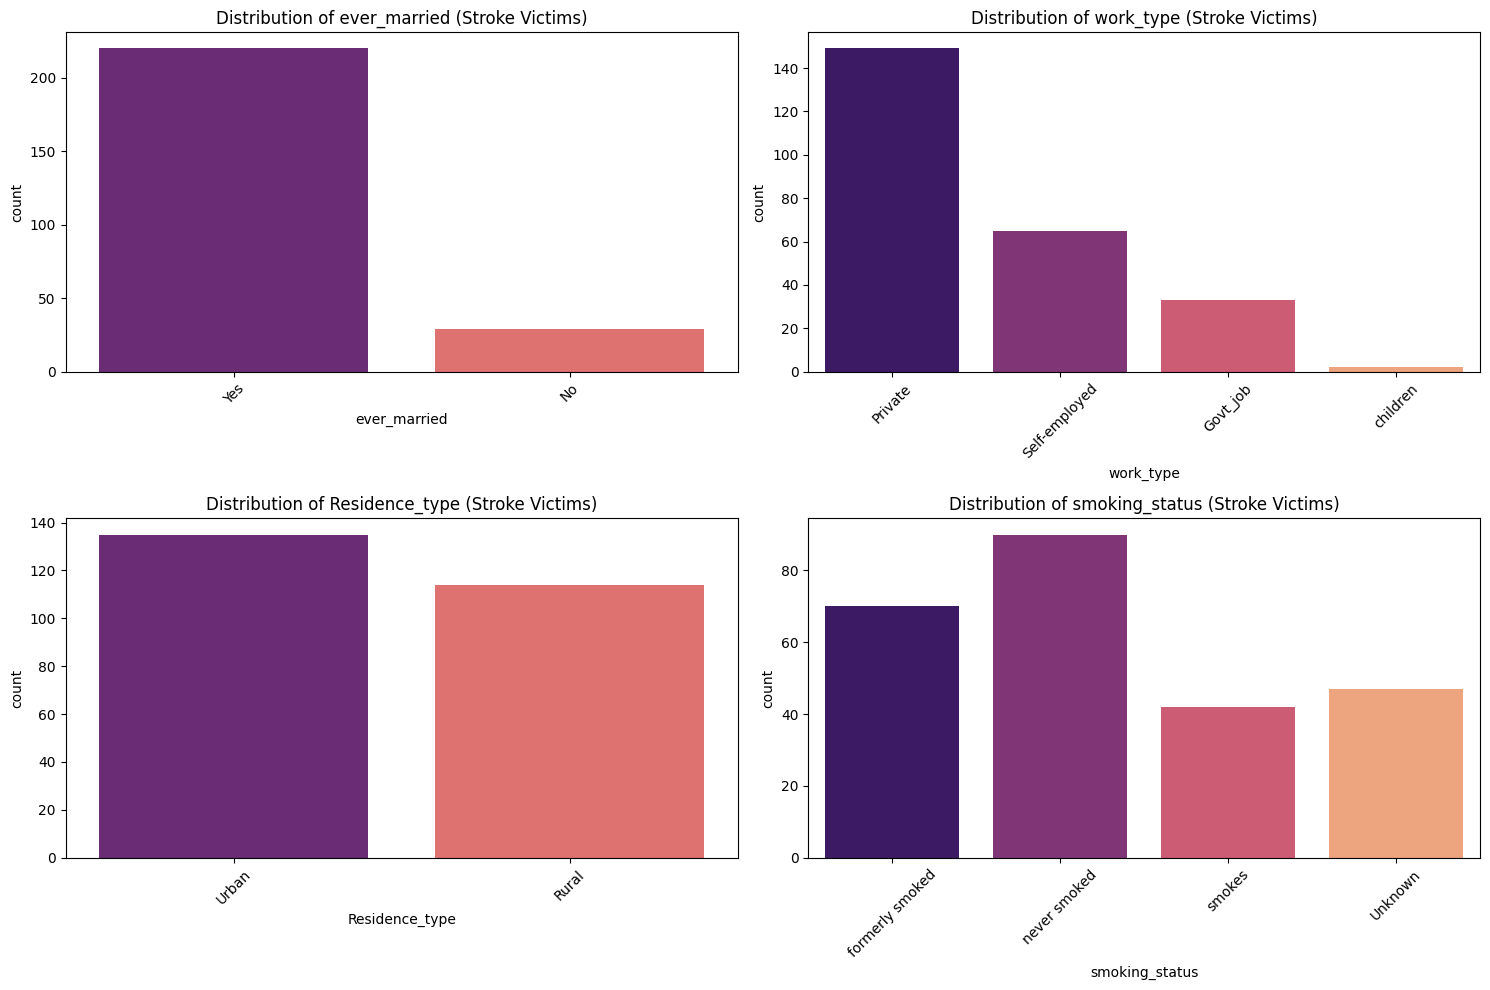

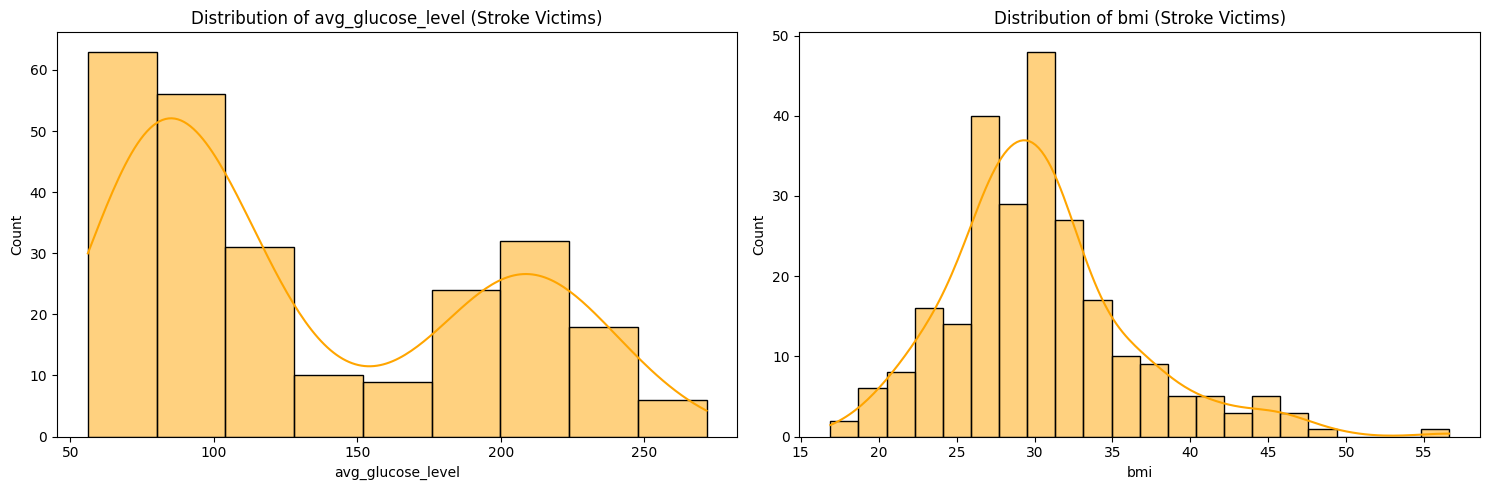

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for stroke victims only
df_stroke = df_updated[df_updated['stroke'] == 1]

# List of columns to visualize
cat_cols = ['ever_married', 'work_type', 'Residence_type', 'smoking_status']
num_cols = ['avg_glucose_level', 'bmi']

# Plot categorical columns for stroke victims
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(data=df_stroke, x=col, ax=axes[i], palette='magma', hue=col, legend=False)
    axes[i].set_title(f'Distribution of {col} (Stroke Victims)')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Plot numerical columns for stroke victims
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for i, col in enumerate(num_cols):
    sns.histplot(df_stroke[col], kde=True, ax=axes[i], color='orange')
    axes[i].set_title(f'Distribution of {col} (Stroke Victims)')
plt.tight_layout()
plt.show()

#checking total values of hypertension , stroke and Heart Disease

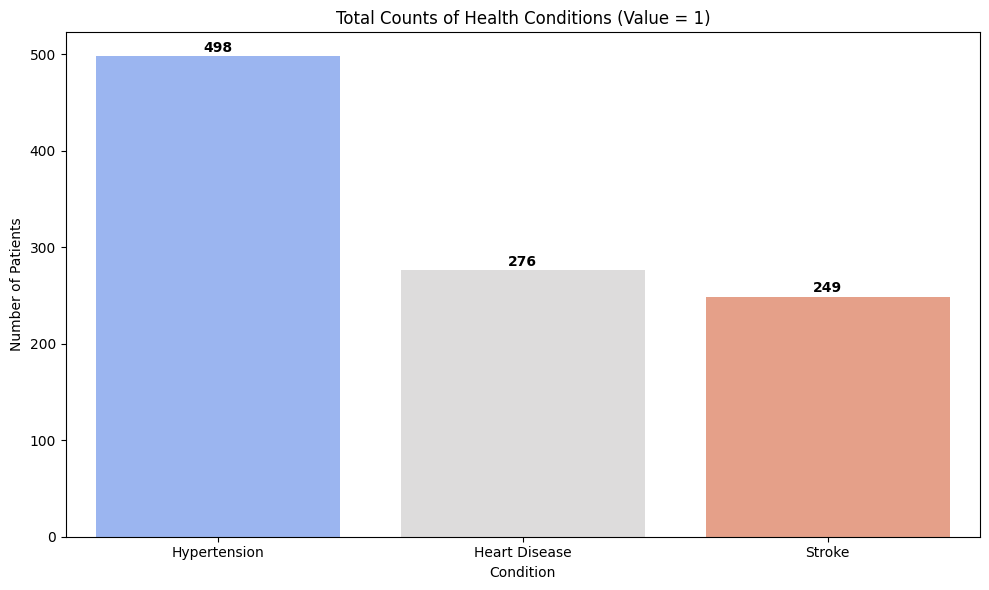

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate totals for each condition where the value is 1
totals = {
    'Hypertension': df_updated['hypertension'].sum(),
    'Heart Disease': df_updated['heart_disease'].sum(),
    'Stroke': df_updated['stroke'].sum()
}

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=list(totals.keys()), y=list(totals.values()), palette='coolwarm', hue=list(totals.keys()), legend=False)

# Add labels and title
plt.title('Total Counts of Health Conditions (Value = 1)')
plt.ylabel('Number of Patients')
plt.xlabel('Condition')

# Add data labels on top of bars
for i, value in enumerate(totals.values()):
    plt.text(i, value + 5, str(value), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()